C:\Users\Momina\OneDrive\Documents\GitHub\banknote-authentication\data\raw\denomination\denomination_dataset
BANKNOTE DATASET EDA

Total Images : 70542

First Five Images
        Filename Denomination
0     10 (1).png           10
1    10 (10).png           10
2   10 (100).png           10
3  10 (1000).png           10
4  10 (1001).png           10

Image Count Per Denomination
Denomination
10       8382
100      6999
1000     7715
2        5105
20      14188
5        6389
50       9837
500     11927
Name: count, dtype: int64


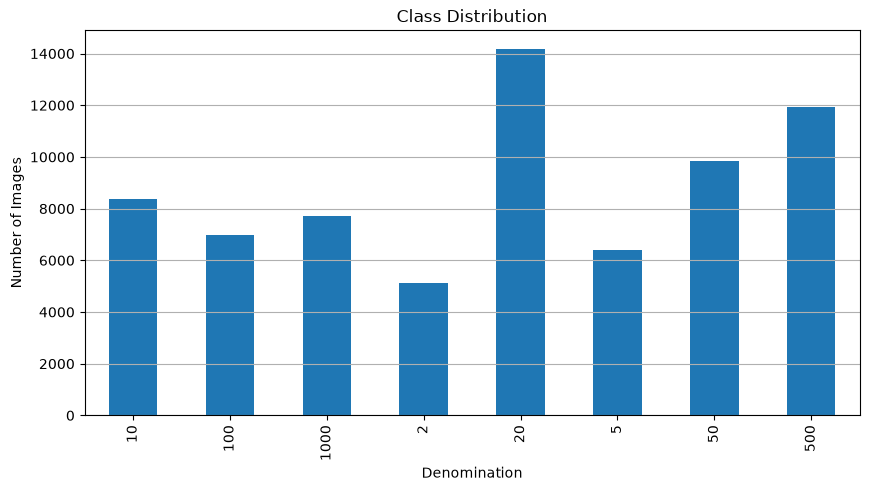


Image Width Statistics
Minimum : 256
Maximum : 256
Average : 256.0

Image Height Statistics
Minimum : 117
Maximum : 117
Average : 117.0

Unique Image Sizes
(256, 117)

Image Modes
{'RGB': 70542}

Image Formats
{'png': 70542}

Corrupted Images : 0


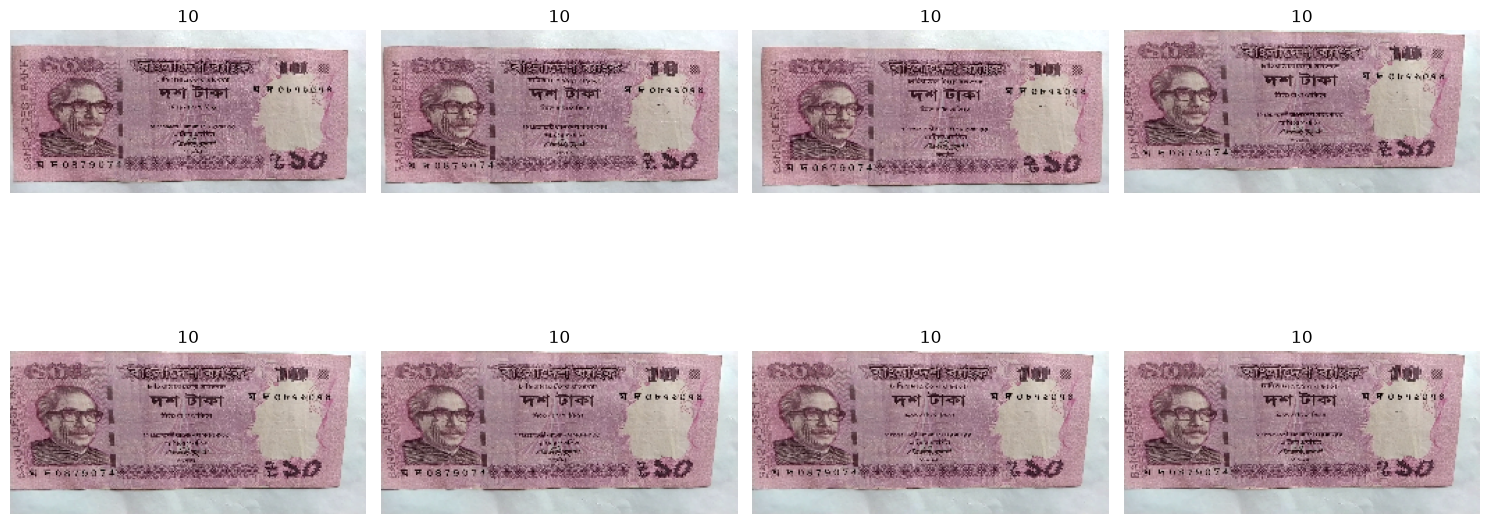


Average Pixel Mean : 0.6125
Average Pixel Std  : 0.1821

EDA SUMMARY
Total Images        : 70542
Number of Classes   : 8
Image Formats       : {'png': 70542}
Image Modes         : {'RGB': 70542}
Unique Sizes        : 1
Corrupted Images    : 0
Average Pixel Mean  : 0.6125
Average Pixel Std   : 0.1821


In [6]:
import os
from PIL import Image
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# DATASET PATH
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATASET_PATH: Path = "C:\\Users\\Momina\\OneDrive\\Documents\\GitHub\\banknote-authentication\\data\\raw\\denomination\\denomination_dataset"

print(DATASET_PATH)

# =====================================================
# CHECK DATASET
# =====================================================

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found:\n{DATASET_PATH}")

# =====================================================
# LOAD IMAGE FILES
# =====================================================

image_files = [
    f for f in os.listdir(DATASET_PATH)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("="*60)
print("BANKNOTE DATASET EDA")
print("="*60)

print(f"\nTotal Images : {len(image_files)}")

# =====================================================
# EXTRACT DENOMINATION LABELS
# =====================================================

labels = []

for file in image_files:

    # Example:
    # 2 (15).png -> 2
    # 100 (6).png -> 100

    label = file.split(" ")[0]

    labels.append(label)

df = pd.DataFrame({
    "Filename": image_files,
    "Denomination": labels
})

print("\nFirst Five Images")

print(df.head())

# =====================================================
# CLASS DISTRIBUTION
# =====================================================

class_counts = df["Denomination"].value_counts().sort_index()

print("\nImage Count Per Denomination")

print(class_counts)

plt.figure(figsize=(10,5))

class_counts.plot(kind="bar")

plt.title("Class Distribution")

plt.xlabel("Denomination")

plt.ylabel("Number of Images")

plt.grid(axis="y")

plt.show()

# =====================================================
# IMAGE SIZE ANALYSIS
# =====================================================

widths = []
heights = []

for file in image_files:

    path = os.path.join(DATASET_PATH,file)

    image = Image.open(path)

    width,height = image.size

    widths.append(width)

    heights.append(height)

print("\nImage Width Statistics")

print("Minimum :",min(widths))

print("Maximum :",max(widths))

print("Average :",round(np.mean(widths),2))

print("\nImage Height Statistics")

print("Minimum :",min(heights))

print("Maximum :",max(heights))

print("Average :",round(np.mean(heights),2))

# =====================================================
# UNIQUE IMAGE SIZES
# =====================================================

sizes = list(zip(widths,heights))

unique_sizes = set(sizes)

print("\nUnique Image Sizes")

for size in unique_sizes:

    print(size)

# =====================================================
# IMAGE MODES
# =====================================================

modes = {}

for file in image_files:

    path = os.path.join(DATASET_PATH,file)

    mode = Image.open(path).mode

    modes[mode] = modes.get(mode,0)+1

print("\nImage Modes")

print(modes)

# =====================================================
# IMAGE FORMATS
# =====================================================

formats = {}

for file in image_files:

    ext = file.split(".")[-1].lower()

    formats[ext] = formats.get(ext,0)+1

print("\nImage Formats")

print(formats)

# =====================================================
# CORRUPTED IMAGE CHECK
# =====================================================

corrupted = []

for file in image_files:

    path = os.path.join(DATASET_PATH,file)

    try:

        Image.open(path).verify()

    except:

        corrupted.append(file)

print("\nCorrupted Images :",len(corrupted))

# =====================================================
# DISPLAY SAMPLE IMAGES
# =====================================================

plt.figure(figsize=(15,8))

sample_files = image_files[:8]

for i,file in enumerate(sample_files):

    path = os.path.join(DATASET_PATH,file)

    image = Image.open(path)

    plt.subplot(2,4,i+1)

    plt.imshow(image)

    plt.title(file.split(" ")[0])

    plt.axis("off")

plt.tight_layout()

plt.show()

# =====================================================
# PIXEL VALUE ANALYSIS
# =====================================================

means = []
stds = []

for file in image_files[:500]:

    path = os.path.join(DATASET_PATH,file)

    image = np.array(Image.open(path))/255.0

    means.append(image.mean())

    stds.append(image.std())

print("\nAverage Pixel Mean :",round(np.mean(means),4))

print("Average Pixel Std  :",round(np.mean(stds),4))

# =====================================================
# SUMMARY
# =====================================================

print("\n"+"="*60)

print("EDA SUMMARY")

print("="*60)

print("Total Images        :",len(image_files))

print("Number of Classes   :",len(class_counts))

print("Image Formats       :",formats)

print("Image Modes         :",modes)

print("Unique Sizes        :",len(unique_sizes))

print("Corrupted Images    :",len(corrupted))

print("Average Pixel Mean  :",round(np.mean(means),4))

print("Average Pixel Std   :",round(np.mean(stds),4))

print("="*60)